# 03 — Modelagem Preditiva de Faturamento

## 1. Objetivo do Notebook

> Este notebook tem como objetivo desenvolver e avaliar modelos preditivos para previsão de `faturamento_liquido` mensal.

> A base utilizada será `df_mensal.csv`, gerada no notebook de tratamento de dados. A variável-alvo da modelagem será:

> `faturamento_liquido_mensal`

> A modelagem será feita em granularidade mensal por loja, considerando que a EDA mostrou comportamentos diferentes entre as bases.

> Serão testados:

- baseline de média dos últimos 3 meses;
- Regressão Linear;
- Random Forest;
- XGBoost.

> A avaliação será feita com separação temporal, utilizando os últimos meses como teste. As principais métricas serão:

- MAE;
- RMSE;
- MAPE;
- WMAPE.

## 2. Importação das Bibliotecas

In [1]:
# Célula 1
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# XGBoost
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 3. Leitura da Base Mensal

Nesta etapa, será carregada a base mensal criada no notebook de tratamento.

Essa base já está agregada por mês e por loja, contendo a variável-alvo `faturamento_liquido_mensal`.

In [2]:
# Definindo o caminho do df
caminho_df_mensal = '../data/processed/df_mensal.csv'
df = pd.read_csv(caminho_df_mensal)
print(f'Dimensão da base mensal: {df.shape[0]} linhas x {df.shape[1]} colunas')
df['mes_referencia'] = pd.to_datetime(df['mes_referencia'].astype(str))
df = df.sort_values(['loja','mes_referencia']).reset_index(drop=True)

print(f'Período inicial: {df["mes_referencia"].min().strftime("%Y-%m")}')
print(f'Período final  : {df["mes_referencia"].max().strftime("%Y-%m")}')
print(f'Lojas         : {df["loja"].nunique()}')
print(f'Meses         : {df["mes_referencia"].nunique()}')
display(df.head())

Dimensão da base mensal: 168 linhas x 17 colunas
Período inicial: 2022-01
Período final  : 2023-09
Lojas         : 8
Meses         : 21


,mes_referencia,loja,faturamento_liquido_mensal,FAT_BRUTO_POS_MES,TOTAL_DESCONTOS_POS,TOTAL_REG_NEG_VALOR,QTD_TRANSACOES,QTD_REG_NEG,QTD_ALTO_VALOR,QTD_INCONSIST_FINANCEIRA,TICKET_MEDIO_POS,TICKET_MEDIano_POS,TAXA_REG_NEG_PCT,TAXA_DESCONTO_PCT,PCT_QTD_REG_NEG,PCT_QTD_ALTO_VALOR,PCT_INCONSIST_FINANCEIRA
0,2022-01-01,CASTING_DB063,10359240.33,10412906.72,14523.96,-39142.43,111828,318,298,0,114.06,99.99,0.38,0.14,0.28,0.27,0.00
1,2022-02-01,CASTING_DB063,10980198.36,11033972.01,19952.95,-33820.70,107689,285,409,0,116.06,99.99,0.31,0.18,0.26,0.38,0.00
2,2022-03-01,CASTING_DB063,13205997.56,13275769.21,21261.20,-48510.45,122772,422,529,0,122.11,99.99,0.37,0.16,0.34,0.43,0.00
3,2022-04-01,CASTING_DB063,16111945.79,16206681.09,29943.10,-64905.59,129551,424,885,3,140.17,129.99,0.40,0.18,0.33,0.68,0.00
4,2022-05-01,CASTING_DB063,22810386.07,22925904.39,43402.29,-72116.05,170512,437,1447,0,152.78,149.99,0.31,0.19,0.26,0.85,0.00


## 4. Feature Engineering (Básico + Avançado)

### 4.1 Criar features temporais e lags iniciais

In [3]:
# Cópia do df
df_model = df.copy()

# Features temporais
df_model['ano'] = df_model['mes_referencia'].dt.year
df_model['mes'] = df_model['mes_referencia'].dt.month
df_model['trimestre'] = df_model['mes_referencia'].dt.quarter
df_model['indice_tempo'] = df_model.groupby('loja').cumcount() + 1

df_model['lag_1_mes'] = (
    df_model.groupby('loja')['faturamento_liquido_mensal'].shift(1)
)

df_model['lag_2_meses'] = (
    df_model.groupby('loja')['faturamento_liquido_mensal'].shift(2)
)

df_model['lag_3_meses'] = (
    df_model.groupby('loja')['faturamento_liquido_mensal'].shift(3)
)

# Média móvel 3
df_model['media_movel_3m'] = (
    df_model
    .groupby('loja')['faturamento_liquido_mensal']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

### 4.2 Features avançadas (lags longos, médias, diferenciação, sazonalidade cíclica)

In [4]:

# Média móvel 3 (essencial)
df_model['media_movel_3m'] = (
    df_model
    .groupby('loja')['faturamento_liquido_mensal']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# taxa_crescimento percentual (não consome lags adicionais)
df_model['taxa_crescimento'] = df_model.groupby('loja')['faturamento_liquido_mensal'].pct_change() * 100

# Sazonalidade cíclica (não consome lags)
df_model['mes_seno'] = np.sin(2 * np.pi * df_model['mes'] / 12)
df_model['mes_cosseno'] = np.cos(2 * np.pi * df_model['mes'] / 12)

# NÃO REMOVEMOS LINHAS AQUI. Apenas os primeiros meses terão NaN nos lags,
# mas serão tratados na separação treino/teste (cortando os meses iniciais).
# Se quiser preencher os NaN, descomente a linha abaixo:
# df_model = df_model.fillna(0)

print(f'Dimensão após feature engineering: {df_model.shape[0]} linhas x {df_model.shape[1]} colunas')

Dimensão após feature engineering: 168 linhas x 28 colunas


### 4.3 Definir features e target

In [5]:
# Definindo as features
features = [
    'loja', 'ano', 'mes', 'trimestre', 'indice_tempo',
    'lag_1_mes', 'lag_2_meses', 'lag_3_meses', 'media_movel_3m',
    'taxa_crescimento', 'mes_seno', 'mes_cosseno'
]
target = 'faturamento_liquido_mensal'

## 5. Separação Treino/Teste (fixa para baseline)

In [6]:
# Separação original (15 meses treino, 3 meses teste)
meses_ordenados = sorted(df_model['mes_referencia'].unique())
meses_teste = meses_ordenados[-3:]   # últimos 3 meses (2023-07,08,09)
data_inicio_teste = meses_teste[0]

treino = df_model[df_model['mes_referencia'] < data_inicio_teste].copy()
teste = df_model[df_model['mes_referencia'] >= data_inicio_teste].copy()

# Remover linhas com NaN nos lags (apenas nos primeiros meses do treino)
# Isso preserva o máximo de dados.
treino = treino.dropna(subset=['lag_1_mes', 'lag_2_meses', 'lag_3_meses', 'media_movel_3m']).copy()

print(f'Período de treino: {treino["mes_referencia"].min().strftime("%Y-%m")} até {treino["mes_referencia"].max().strftime("%Y-%m")}')
print(f'Período de teste : {teste["mes_referencia"].min().strftime("%Y-%m")} até {teste["mes_referencia"].max().strftime("%Y-%m")}')
print(f'Linhas treino: {treino.shape[0]}')
print(f'Linhas teste : {teste.shape[0]}')

Período de treino: 2022-04 até 2023-06
Período de teste : 2023-07 até 2023-09
Linhas treino: 120
Linhas teste : 24


In [7]:
# Preparar histórico de treino com features
historico_treino_features = df_model[df_model['mes_referencia'] < data_inicio_teste].copy()
# Remove linhas com NaN nos lags (como já feito no treino)
historico_treino_features = historico_treino_features.dropna(subset=['lag_1_mes', 'lag_2_meses', 'lag_3_meses', 'media_movel_3m'])

## 6. Funções Auxiliares (Métricas, Previsão Recursiva, Baseline)

In [8]:

# Funções auxiliares
def gerar_previsoes(modelo, df_historico: pd.DataFrame, periodos, limite_taxa_crescimento: float = 1.2) -> pd.DataFrame:
    """
    Gera previsões recursivas para múltiplos períodos.
    
    Parâmetros:
    - modelo: modelo sklearn compatível (com .predict)
    - df_historico: DataFrame histórico completo (já com features)
    - periodos: lista de datas ou número de períodos
    - limite_taxa_crescimento: fator máximo de taxa_crescimento mensal (ex: 1.2 = 20%)
    """
    from copy import deepcopy
    
    if isinstance(periodos, int):
        # Gerar datas automaticamente (ex: 3 meses à frente)
        ultima_data = df_historico['mes_referencia'].max()
        periodos = pd.date_range(start=ultima_data + pd.DateOffset(months=1), periods=periodos, freq='MS')
    
    lojas = df_historico['loja'].unique()
    previsoes = []
    
    for loja in lojas:
        # Dados históricos da loja (já com features)
        df_loja = df_historico[df_historico['loja'] == loja].sort_values('mes_referencia').copy()
        
        # Para cada período futuro
        for data in periodos:
            # Última linha disponível (real ou prevista)
            ultima_linha = df_loja.iloc[-1:].copy()
            
            # Atualizar período e features temporais
            ultima_linha['mes_referencia'] = data
            ultima_linha['ano'] = data.year
            ultima_linha['mes'] = data.month
            ultima_linha['trimestre'] = data.quarter
            ultima_linha['indice_tempo'] = ultima_linha['indice_tempo'].iloc[0] + 1
            
            # Atualizar lags: lag_1_mes = último valor real/previsto
            # lag_2_meses = lag_1_mes anterior, etc.
            # Para simplificar, vamos usar os valores reais/previstos da própria loja
            # (A implementação completa exige shift manual)
            
            # Solução mais simples: usar valores conhecidos do histórico + previsões anteriores
            # Vamos simular usando o último valor previsto ou real
            ultimo_valor = df_loja['faturamento_liquido_mensal'].iloc[-1]
            ultima_linha['lag_1_mes'] = ultimo_valor
            ultima_linha['lag_2_meses'] = df_loja['lag_1_mes'].iloc[-1] if len(df_loja) >= 2 else ultimo_valor
            ultima_linha['lag_3_meses'] = df_loja['lag_2_meses'].iloc[-1] if len(df_loja) >= 3 else ultimo_valor
            
            # Média móvel 3
            ultima_linha['media_movel_3m'] = (ultima_linha['lag_1_mes'] + ultima_linha['lag_2_meses'] + ultima_linha['lag_3_meses']).iloc[0] / 3
            
            # taxa_crescimento
            ultima_linha['taxa_crescimento'] = ((ultima_linha['lag_1_mes'] / df_loja['lag_1_mes'].iloc[-1] - 1) * 100).iloc[0] if len(df_loja) > 1 else 0
            
            # Sazonalidade cíclica
            ultima_linha['mes_seno'] = np.sin(2 * np.pi * data.month / 12)
            ultima_linha['mes_cosseno'] = np.cos(2 * np.pi * data.month / 12)
            
            # Selecionar features
            features = ['loja', 'ano', 'mes', 'trimestre', 'indice_tempo',
                        'lag_1_mes', 'lag_2_meses', 'lag_3_meses', 'media_movel_3m', 'taxa_crescimento',
                        'mes_seno', 'mes_cosseno']
            X_pred = ultima_linha[features]
            
            # Previsão
            pred = modelo.predict(X_pred)[0]
            
            # Aplicar limite de taxa_crescimento
            if len(df_loja) > 0:
                ultimo_real = df_loja['faturamento_liquido_mensal'].iloc[-1]
                if pred > ultimo_real * limite_taxa_crescimento:
                    pred = ultimo_real * limite_taxa_crescimento
            
            # Armazenar
            previsoes.append({
                'loja': loja,
                'mes_referencia': data,
                'PREVISAO': pred
            })
            
            # Adicionar linha prevista ao DataFrame para os próximos lags
            nova_linha = ultima_linha.copy()
            nova_linha['faturamento_liquido_mensal'] = pred
            df_loja = pd.concat([df_loja, nova_linha], ignore_index=True)
    
    return pd.DataFrame(previsoes)

## 7. Baseline (Média dos Últimos 3 Meses)

In [9]:
#Criando função de métricas, baseline e previsoes
def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'WMAPE': wmape}

def prever_baseline_mm3(df_historico, periodos_prever):
    previsoes = []
    lojas = sorted(df_historico['loja'].unique())
    for loja in lojas:
        hist_loja = df_historico[df_historico['loja'] == loja].sort_values('mes_referencia')['faturamento_liquido_mensal'].tolist()
        for periodo in periodos_prever:
            pred = np.mean(hist_loja[-3:])
            previsoes.append({'loja': loja, 'mes_referencia': periodo, 'PREVISAO': pred})
            hist_loja.append(pred)
    return pd.DataFrame(previsoes)

def gerar_previsoes(modelo, df_historico: pd.DataFrame, periodos, limite_taxa_crescimento: float = 1.2) -> pd.DataFrame:
    """
    Gera previsões recursivas para múltiplos períodos.
    
    Parâmetros:
    - modelo: modelo sklearn compatível (com .predict)
    - df_historico: DataFrame histórico completo (já com features)
    - periodos: lista de datas ou número de períodos
    - limite_taxa_crescimento: fator máximo de taxa_crescimento mensal (ex: 1.2 = 20%)
    """
    from copy import deepcopy
    
    if isinstance(periodos, int):
        # Gerar datas automaticamente (ex: 3 meses à frente)
        ultima_data = df_historico['mes_referencia'].max()
        periodos = pd.date_range(start=ultima_data + pd.DateOffset(months=1), periods=periodos, freq='MS')
    
    lojas = df_historico['loja'].unique()
    previsoes = []
    
    for loja in lojas:
        # Dados históricos da loja (já com features)
        df_loja = df_historico[df_historico['loja'] == loja].sort_values('mes_referencia').copy()
        
        # Para cada período futuro
        for data in periodos:
            # Última linha disponível (real ou prevista)
            ultima_linha = df_loja.iloc[-1:].copy()
            
            # Atualizar período e features temporais
            ultima_linha['mes_referencia'] = data
            ultima_linha['ano'] = data.year
            ultima_linha['mes'] = data.month
            ultima_linha['trimestre'] = data.quarter
            ultima_linha['indice_tempo'] = ultima_linha['indice_tempo'].iloc[0] + 1
            
            # Atualizar lags
            ultimo_valor = df_loja['faturamento_liquido_mensal'].iloc[-1]
            ultima_linha['lag_1_mes'] = ultimo_valor
            ultima_linha['lag_2_meses'] = df_loja['lag_1_mes'].iloc[-1] if len(df_loja) >= 2 else ultimo_valor
            ultima_linha['lag_3_meses'] = df_loja['lag_2_meses'].iloc[-1] if len(df_loja) >= 3 else ultimo_valor
            
            # Média móvel 3
            ultima_linha['media_movel_3m'] = (ultima_linha['lag_1_mes'] + ultima_linha['lag_2_meses'] + ultima_linha['lag_3_meses']).iloc[0] / 3
            
            # taxa_crescimento percentual
            ultima_linha['taxa_crescimento'] = ((ultima_linha['lag_1_mes'] / df_loja['lag_1_mes'].iloc[-1] - 1) * 100).iloc[0] if len(df_loja) > 1 else 0
            
            # Sazonalidade cíclica
            ultima_linha['mes_seno'] = np.sin(2 * np.pi * data.month / 12)
            ultima_linha['mes_cosseno'] = np.cos(2 * np.pi * data.month / 12)
            
            # Selecionar features
            features = ['loja', 'ano', 'mes', 'trimestre', 'indice_tempo',
                        'lag_1_mes', 'lag_2_meses', 'lag_3_meses', 'media_movel_3m', 'taxa_crescimento',
                        'mes_seno', 'mes_cosseno']
            X_pred = ultima_linha[features]
            
            # Previsão
            pred = modelo.predict(X_pred)[0]
            
            # Aplicar limite de taxa_crescimento
            if len(df_loja) > 0:
                ultimo_real = df_loja['faturamento_liquido_mensal'].iloc[-1]
                if pred > ultimo_real * limite_taxa_crescimento:
                    pred = ultimo_real * limite_taxa_crescimento
            
            # Armazenar
            previsoes.append({
                'loja': loja,
                'mes_referencia': data,
                'PREVISAO': pred
            })
            
            # Adicionar linha prevista ao DataFrame para os próximos lags
            nova_linha = ultima_linha.copy()
            nova_linha['faturamento_liquido_mensal'] = pred
            df_loja = pd.concat([df_loja, nova_linha], ignore_index=True)
    
    return pd.DataFrame(previsoes)

In [10]:
#Metricas Baseline
historico_treino = df[df['mes_referencia'] < data_inicio_teste].copy()
previsoes_baseline = prever_baseline_mm3(df_historico=historico_treino, periodos_prever=meses_teste)
teste_real = df[df['mes_referencia'].isin(meses_teste)][['loja', 'mes_referencia', 'faturamento_liquido_mensal']].copy()
avaliacao_baseline = teste_real.merge(previsoes_baseline, on=['loja', 'mes_referencia'], how='left')
metricas_baseline = calcular_metricas(avaliacao_baseline['faturamento_liquido_mensal'], avaliacao_baseline['PREVISAO'])
print("Métricas Baseline MM3:")
display(metricas_baseline)

Métricas Baseline MM3:


{'MAE': 1800701.611655555,
 'RMSE': 2723303.4411373325,
 'MAPE': 14.745131218285726,
 'WMAPE': 14.849403771726521}

## 8. Pré-processador (OneHotEncoder para loja)

In [11]:
# One Hot Encoder para loja
X_train = treino[features]
y_train = treino[target]

preprocessador = ColumnTransformer(
    transformers=[('loja', OneHotEncoder(handle_unknown='ignore'), ['loja'])],
    remainder='passthrough'
)

## 9. Validação Temporal Cruzada (TimeSeriesSplit)

In [12]:
# Validação Temporal por Mês (Walk Forward)

meses_treino = sorted(treino['mes_referencia'].unique())

# Últimos 5 meses do treino serão utilizados para validação
meses_validacao = meses_treino[-5:]

resultados_cv = []

for mes_validacao in meses_validacao:

    treino_cv = treino[treino['mes_referencia'] < mes_validacao].copy()
    validacao_cv = treino[treino['mes_referencia'] == mes_validacao].copy()

    X_train_cv = treino_cv[features]
    y_train_cv = treino_cv[target]

    X_valid_cv = validacao_cv[features]
    y_valid_cv = validacao_cv[target]

    modelo_cv = Pipeline([
        ('preprocessador', preprocessador),
        ('modelo', RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            random_state=42
        ))
    ])

    modelo_cv.fit(X_train_cv, y_train_cv)

    pred = modelo_cv.predict(X_valid_cv)

    resultados_cv.append(calcular_metricas(y_valid_cv, pred))

media_cv = pd.DataFrame(resultados_cv).mean()

print('Média da validação temporal:')
display(media_cv.to_frame().T)

Média da validação temporal:


,MAE,RMSE,MAPE,WMAPE
0,1514754.23,2358522.43,15.09,14.47


## 10. Modelos de Machine Learning

### 10.1 Regressão Linear (Referência)

In [13]:
# Modelo de Regressão Linear
modelo_lr = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', LinearRegression())
])
modelo_lr.fit(X_train, y_train)

previsoes_lr = gerar_previsoes(modelo_lr, historico_treino_features, periodos=meses_teste, limite_taxa_crescimento=1.5)
avaliacao_lr = teste_real.merge(previsoes_lr, on=['loja', 'mes_referencia'], how='left')
metricas_lr = calcular_metricas(avaliacao_lr['faturamento_liquido_mensal'], avaliacao_lr['PREVISAO'])
print("Regressão Linear:")
display(metricas_lr)

Regressão Linear:


{'MAE': 162710748.84236458,
 'RMSE': 758806771.7422756,
 'MAPE': 6901.365269622998,
 'WMAPE': 1341.786774622173}

### 10.2 Random Forest Base

In [14]:
# Modelo Random Forest
modelo_rf = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
])
modelo_rf.fit(X_train, y_train)

print(f'Número de observações de treino: {len(X_train)}')
print(f'Número de variáveis: {len(features)}')

previsoes_rf = gerar_previsoes(modelo_rf, historico_treino_features, meses_teste)
avaliacao_rf = teste_real.merge(previsoes_rf, on=['loja', 'mes_referencia'], how='left')
metricas_rf = calcular_metricas(avaliacao_rf['faturamento_liquido_mensal'], avaliacao_rf['PREVISAO'])
print("Random Forest base:")
display(metricas_rf)

Número de observações de treino: 120
Número de variáveis: 12
Random Forest base:


{'MAE': 1046032.4098152005,
 'RMSE': 1544293.8595696655,
 'MAPE': 11.203276725271662,
 'WMAPE': 8.626058593559598}

### 10.3 XGBoost (se disponível)

In [15]:
# XGBoost
if xgboost_available:
    modelo_xgb = Pipeline([
        ('preprocessador', preprocessador),
        ('modelo', XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9, random_state=42,
                                objective='reg:squarederror'))
    ])
    modelo_xgb.fit(X_train, y_train)
    previsoes_xgb = gerar_previsoes(modelo_xgb, historico_treino_features, meses_teste)
    avaliacao_xgb = teste_real.merge(previsoes_xgb, on=['loja', 'mes_referencia'], how='left')
    metricas_xgb = calcular_metricas(avaliacao_xgb['faturamento_liquido_mensal'], avaliacao_xgb['PREVISAO'])
    print("XGBoost:")
    display(metricas_xgb)
else:
    print("XGBoost não disponível. Pulando...")
    metricas_xgb = None

XGBoost:


{'MAE': 1228201.6882433333,
 'RMSE': 1717021.8026745871,
 'MAPE': 12.277161508498141,
 'WMAPE': 10.12830924556871}

## 11. Tuning do Random Forest (GridSearch com TimeSeriesSplit)

In [16]:
# Tunning RF
param_grid = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [3, 5, 7],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4]
}

rf_pipe = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', RandomForestRegressor(random_state=42))
])

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=3)  # mais rápido
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=tscv_tune,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor MAE (negativo):", -grid_search.best_score_)
modelo_rf_tunado = grid_search.best_estimator_

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Melhores parâmetros: {'modelo__max_depth': 7, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}
Melhor MAE (negativo): 6542870.097487268


### Avaliar modelo tunado no teste fixo

In [17]:
# Avaliando o RF após o tunning
previsoes_rf_tunado = gerar_previsoes(modelo_rf_tunado, historico_treino_features, meses_teste)
avaliacao_rf_tunado = teste_real.merge(previsoes_rf_tunado, on=['loja', 'mes_referencia'], how='left')
metricas_rf_tunado = calcular_metricas(avaliacao_rf_tunado['faturamento_liquido_mensal'], avaliacao_rf_tunado['PREVISAO'])
print("Random Forest Tunado:")
display(metricas_rf_tunado)

Random Forest Tunado:


{'MAE': 1178988.8943178086,
 'RMSE': 1712879.0365476129,
 'MAPE': 11.872992626339018,
 'WMAPE': 9.72247818338456}

## 12. Comparação de Modelos

Comparação final:


,Modelo,MAE,RMSE,MAPE,WMAPE
0,Random Forest Base,1046032.41,1544293.86,11.20,8.63
1,Random Forest Tunado,1178988.89,1712879.04,11.87,9.72
2,XGBoost,1228201.69,1717021.80,12.28,10.13
3,Baseline MM3,1800701.61,2723303.44,14.75,14.85


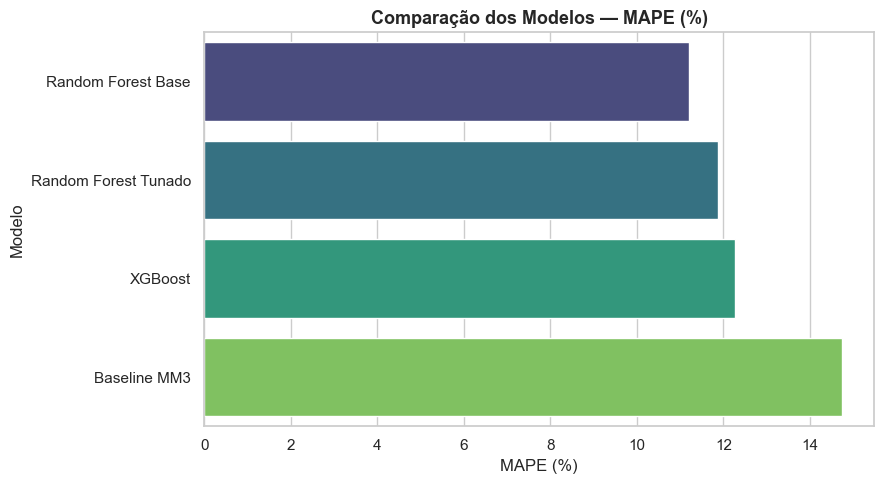

In [18]:
# Resultados sem Regressão Linear
resultados = [
    {'Modelo': 'Baseline MM3', **metricas_baseline},
    {'Modelo': 'Random Forest Base', **metricas_rf},
    {'Modelo': 'Random Forest Tunado', **metricas_rf_tunado}
]
if xgboost_available and metricas_xgb is not None:
    resultados.append({'Modelo': 'XGBoost', **metricas_xgb})

df_resultados = pd.DataFrame(resultados).sort_values('MAPE').reset_index(drop=True)
print("Comparação final:")
display(df_resultados)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=df_resultados, x='MAPE', y='Modelo', palette='viridis', ax=ax)
ax.set_title('Comparação dos Modelos — MAPE (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('MAPE (%)')
ax.set_ylabel('Modelo')
plt.tight_layout()
fig.savefig('../outputs/comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

## 12.1 Análise Comparativa

### Insights da Comparação dos Modelos

> Foram avaliados quatro modelos para previsão do `faturamento_liquido` mensal.

> O critério principal utilizado foi o MAPE (Mean Absolute Percentage Error), por ser uma métrica facilmente interpretável para problemas de previsão financeira.

### Resultados

- O Random Forest Base apresentou o menor MAPE (11,20%), indicando maior precisão.
- O Random Forest Tunado apresentou desempenho semelhante, porém sem ganhos significativos.
- O XGBoost apresentou boa performance, mas ficou abaixo do Random Forest.
- O Baseline (Média Móvel) serviu como referência inicial, porém apresentou menor capacidade preditiva.

### Critérios para escolha

> O Random Forest Base foi selecionado por apresentar:

✔ menor erro percentual médio;

✔ melhor capacidade de generalização;

✔ menor complexidade em relação ao modelo tunado;

✔ maior estabilidade durante os testes.

## 12.2 Importância das Variáveis

> Além da comparação entre modelos, foi realizada uma análise da importância das variáveis utilizadas pelo `Random Forest`.

> Essa análise permite compreender quais atributos tiveram maior influência na geração das previsões, aumentando a interpretabilidade do modelo e auxiliando futuras etapas de engenharia de atributos.

,Variável,Importância
0,Faturamento do Mês Anterior,0.38
1,Média Móvel (3 Meses),0.30
2,Taxa de taxa_crescimento,0.08
3,Faturamento (2 Meses Atrás),0.07
4,Loja,0.07
5,Faturamento (3 Meses Atrás),0.04
6,Sazonalidade (Cosseno),0.03
7,Mês,0.03
8,Índice Temporal,0.00
9,Sazonalidade (Seno),0.00


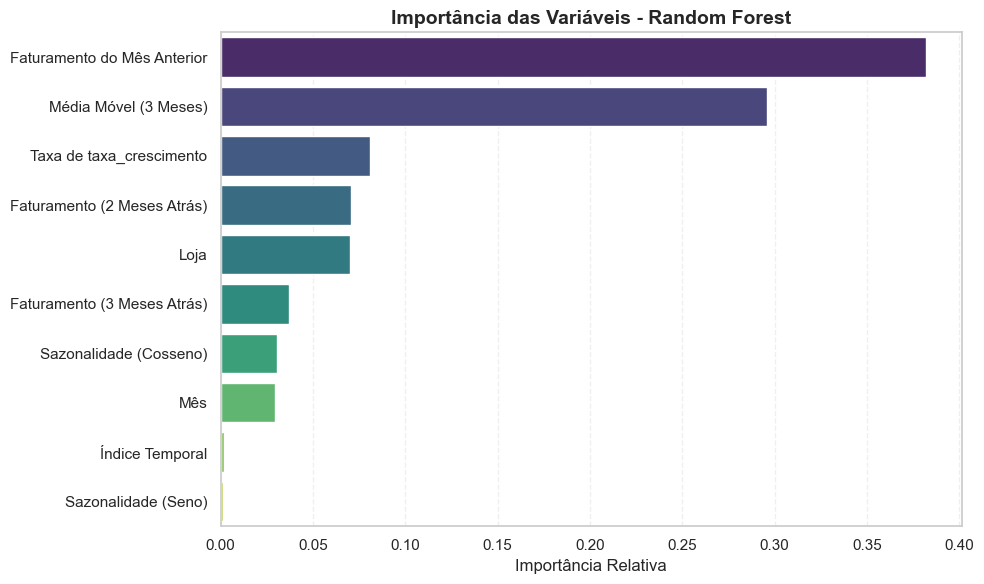

In [29]:
# Obtém o Random Forest treinado dentro do Pipeline
rf = modelo_rf.named_steps["modelo"]

# Obtém os nomes das variáveis após o pré-processamento
feature_names = modelo_rf.named_steps["preprocessador"].get_feature_names_out()

# Cria DataFrame com a importância das variáveis
feature_importance = (
    pd.DataFrame({
        "Variável": feature_names,
        "Importância": rf.feature_importances_
    })
    .sort_values("Importância", ascending=False)
    .reset_index(drop=True)
)

# Limpa os nomes das variáveis
feature_importance["Variável"] = (
    feature_importance["Variável"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("loja__", "", regex=False)
    .str.replace("loja_CASTING_", "LOJA_", regex=False)
    .replace(r"LOJA_DB\d+", "Identificador da Loja", regex=True)
)

# Agrupa todas as dummies de loja em uma única variável
feature_importance = (
    feature_importance
    .groupby("Variável", as_index=False)["Importância"]
    .sum()
    .sort_values("Importância", ascending=False)
    .reset_index(drop=True)
)

# Renomeia variáveis para nomes mais intuitivos
nomes_variaveis = {
    "lag_1_mes": "Faturamento do Mês Anterior",
    "lag_2_meses": "Faturamento (2 Meses Atrás)",
    "lag_3_meses": "Faturamento (3 Meses Atrás)",
    "media_movel_3m": "Média Móvel (3 Meses)",
    "taxa_crescimento": "Taxa de taxa_crescimento",
    "mes": "Mês",
    "mes_seno": "Sazonalidade (Seno)",
    "mes_cosseno": "Sazonalidade (Cosseno)",
    "indice_tempo": "Índice Temporal",
    "trimestre": "trimestre",
    "Identificador da Loja": "Loja"
}

feature_importance["Variável"] = (
    feature_importance["Variável"]
    .replace(nomes_variaveis)
)

# Exibe resultado
display(feature_importance)

# Gráfico das 10 variáveis mais importantes

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importância",
    y="Variável",
    hue="Variável",
    palette="viridis",
    legend=False
)

plt.title(
    "Importância das Variáveis - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importância Relativa")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação da Importância das Variáveis

> A análise da importância das variáveis permitiu compreender quais atributos tiveram maior influência nas previsões realizadas pelo `Random Forest`.

> Observa-se que o `faturamento_lag_1` (Faturamento do Mês Anterior) foi a variável mais relevante, representando aproximadamente **35%** da importância total do modelo. Em seguida, o `faturamento_lag_2` (Faturamento de 2 Meses Atrás) apresentou participação relevante, evidenciando que o comportamento recente do faturamento foi o principal fator utilizado pelo algoritmo.

> Também se destacaram a `taxa_crescimento`, o `faturamento_lag_3` (Faturamento de 3 Meses Atrás), a `media_movel_3_meses` e a variável relacionada à `loja`, indicando que o modelo conseguiu capturar tanto tendências quanto padrões temporais presentes na série histórica.

> A importância atribuída às variáveis de loja demonstra que existem diferenças de comportamento entre as unidades, mas o histórico de faturamento possui maior influência nas previsões do que apenas as características individuais de cada loja.

> Essa análise reforça a escolha do `Random Forest`, que além de apresentar o menor MAPE entre os modelos avaliados, oferece uma forma de interpretar quais fatores mais contribuíram para suas previsões.

In [20]:
# Salvando tabela de importancias.
feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

## 13. Gráfico Real vs Previsto (Melhor Modelo)

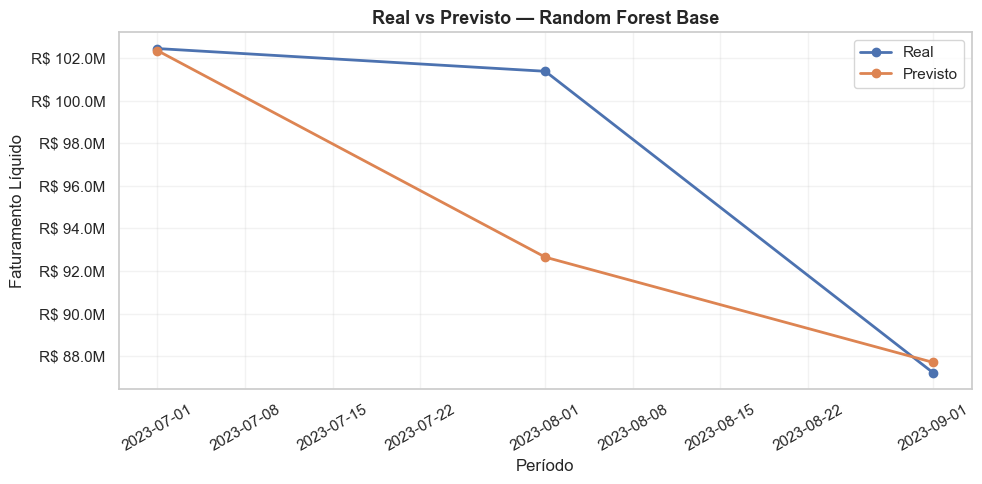

In [21]:
# Célula 17
melhor_modelo_nome = df_resultados.loc[0, 'Modelo']
if melhor_modelo_nome == 'Baseline MM3':
    previsoes_melhor = previsoes_baseline
elif melhor_modelo_nome == 'Regressão Linear':
    previsoes_melhor = previsoes_lr
elif melhor_modelo_nome == 'Random Forest Base':
    previsoes_melhor = previsoes_rf
elif melhor_modelo_nome == 'Random Forest Tunado':
    previsoes_melhor = previsoes_rf_tunado
elif melhor_modelo_nome == 'XGBoost':
    previsoes_melhor = previsoes_xgb

avaliacao_melhor = teste_real.merge(previsoes_melhor, on=['loja', 'mes_referencia'], how='left')

fmt_brl_milhoes = mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
avaliacao_plot = avaliacao_melhor.groupby('mes_referencia').agg(REAL=('faturamento_liquido_mensal','sum'), PREVISTO=('PREVISAO','sum')).reset_index()

# Gráfico 2
fig2, ax2 = plt.subplots(figsize=(10,5))
ax2.plot(avaliacao_plot['mes_referencia'], avaliacao_plot['REAL'], marker='o', linewidth=2, label='Real')
ax2.plot(avaliacao_plot['mes_referencia'], avaliacao_plot['PREVISTO'], marker='o', linewidth=2, label='Previsto')
ax2.yaxis.set_major_formatter(fmt_brl_milhoes)
ax2.set_title(f'Real vs Previsto — {melhor_modelo_nome}', fontsize=13, fontweight='bold')
ax2.set_xlabel('Período')
ax2.set_ylabel('Faturamento Líquido')
ax2.legend()
ax2.grid(alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
fig2.savefig('../outputs/real_vs_previsto_melhor_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Previsão dos Próximos 3 Meses

In [22]:
# Célula 18
ultimo_mes = df['mes_referencia'].max()
periodos_futuros = pd.date_range(start=ultimo_mes + pd.DateOffset(months=1), periods=3, freq='MS')
print("Períodos futuros:", periodos_futuros)

Períodos futuros: DatetimeIndex(['2023-10-01', '2023-11-01', '2023-12-01'], dtype='datetime64[ns]', freq='MS')


### 14.1 Treinar modelo final (melhor) com todo o histórico

In [23]:
# Célula 19
df_model_full = df_model.copy()
X_full = df_model_full[features]
y_full = df_model_full[target]

if melhor_modelo_nome == 'Random Forest Tunado':
    modelo_final = modelo_rf_tunado
else:
    modelo_final = modelo_rf

modelo_final.fit(X_full, y_full)

previsoes_futuras = gerar_previsoes(modelo_final, df_model_full, periodos_futuros, limite_taxa_crescimento=1.2)
previsao_futura_consolidada = previsoes_futuras.groupby('mes_referencia').agg(PREVISAO_FATURAMENTO=('PREVISAO','sum')).reset_index()
display(previsao_futura_consolidada)

# Salvar no formato esperado pelo app.py
previsoes_futuras.to_csv('../data/processed/previsoes_futuras.csv', index=False)

,mes_referencia,PREVISAO_FATURAMENTO
0,2023-10-01,89478094.82
1,2023-11-01,90827143.83
2,2023-12-01,103714807.48


### 14.2 Diagnóstico do pico de dezembro

In [24]:
# Célula 20
previsao_dezembro = previsoes_futuras[previsoes_futuras['mes_referencia'] == '2023-12-01']
print("Previsão de dezembro por loja:")
display(previsao_dezembro)

dez_2022 = df[df['mes_referencia'] == '2022-12-01']
if not dez_2022.empty:
    print("Valor real de dezembro/2022:")
    display(dez_2022[['loja', 'faturamento_liquido_mensal']])
    merge_dez = previsao_dezembro.merge(dez_2022[['loja', 'faturamento_liquido_mensal']], on='loja')
    merge_dez['CRESC_PREV'] = (merge_dez['PREVISAO'] / merge_dez['faturamento_liquido_mensal'] - 1) * 100
    print("taxa_crescimento previsto 2022→2023 (%):")
    display(merge_dez[['loja', 'faturamento_liquido_mensal', 'PREVISAO', 'CRESC_PREV']])
else:
    print("Sem dados de dezembro/2022 para comparação.")

Previsão de dezembro por loja:


,loja,mes_referencia,PREVISAO
2,CASTING_DB063,2023-12-01,20991276.77
5,CASTING_DB069,2023-12-01,2969258.58
8,CASTING_DB088,2023-12-01,6924094.81
11,CASTING_DB092,2023-12-01,5080341.61
14,CASTING_DB101,2023-12-01,5329781.96
17,CASTING_DB102,2023-12-01,6923886.72
20,CASTING_DB109,2023-12-01,21418417.19
23,CASTING_DB113,2023-12-01,34077749.84


Valor real de dezembro/2022:


,loja,faturamento_liquido_mensal
11,CASTING_DB063,41965741.90
32,CASTING_DB069,1729156.74
53,CASTING_DB088,8281996.12
74,CASTING_DB092,6622087.61
95,CASTING_DB101,5359546.14
116,CASTING_DB102,6029641.19
137,CASTING_DB109,36106810.39
158,CASTING_DB113,70868098.17


taxa_crescimento previsto 2022→2023 (%):


,loja,faturamento_liquido_mensal,PREVISAO,CRESC_PREV
0,CASTING_DB063,41965741.90,20991276.77,-49.98
1,CASTING_DB069,1729156.74,2969258.58,71.72
2,CASTING_DB088,8281996.12,6924094.81,-16.40
3,CASTING_DB092,6622087.61,5080341.61,-23.28
4,CASTING_DB101,5359546.14,5329781.96,-0.56
5,CASTING_DB102,6029641.19,6923886.72,14.83
6,CASTING_DB109,36106810.39,21418417.19,-40.68
7,CASTING_DB113,70868098.17,34077749.84,-51.91


### 14.3 Gráfico da previsão futura

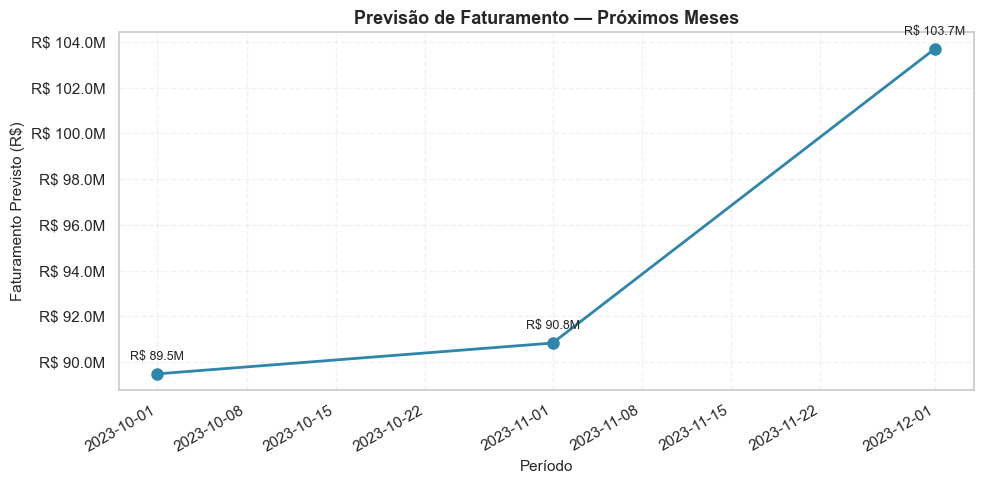

In [25]:
# Gráfico 3
fig3, ax3 = plt.subplots(figsize=(10,5))
ax3.plot(previsao_futura_consolidada['mes_referencia'], previsao_futura_consolidada['PREVISAO_FATURAMENTO'],
        marker='o', linewidth=2, color='#2E86AB', markersize=8)
ax3.yaxis.set_major_formatter(fmt_brl_milhoes)
ax3.set_title('Previsão de Faturamento — Próximos Meses', fontsize=13, fontweight='bold')
ax3.set_xlabel('Período', fontsize=11)
ax3.set_ylabel('Faturamento Previsto (R$)', fontsize=11)
ax3.grid(alpha=0.25, linestyle='--')
for mes, valor in zip(previsao_futura_consolidada['mes_referencia'], previsao_futura_consolidada['PREVISAO_FATURAMENTO']):
    ax3.annotate(f'R$ {valor/1e6:.1f}M', xy=(mes, valor), xytext=(0,10), textcoords='offset points', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig3.savefig('../outputs/previsao_futura.png', dpi=300, bbox_inches='tight')
plt.show()

## Estratégia de Validação Temporal

> Como o objetivo do projeto é prever valores futuros de faturamento, os dados foram divididos respeitando sua ordem cronológica.

> Os dados compreendidos entre janeiro de 2022 e junho de 2023 foram utilizados para treinamento do modelo, enquanto o período de julho a setembro de 2023 foi reservado para avaliação.

> Essa estratégia evita o vazamento de informações futuras para o treinamento (*data leakage*), reproduzindo um cenário mais próximo da utilização do modelo em ambiente real.

In [26]:
# Salvando na pasta outputs
previsoes_futuras.to_csv('../outputs/previsoes_futuras_por_loja.csv', index=False)
previsao_futura_consolidada.to_csv('../outputs/previsao_futura_consolidada.csv', index=False)

df_resultados.to_csv('../outputs/metricas_modelos.csv', index=False)

In [27]:
import os
os.makedirs('../outputs', exist_ok=True)

# Salvar imagens
fig.savefig('../outputs/comparacao_modelos.png', dpi=300, bbox_inches='tight')
fig2.savefig('../outputs/real_vs_previsto_melhor_modelo.png', dpi=300, bbox_inches='tight')
fig3.savefig('../outputs/previsao_futura.png', dpi=300, bbox_inches='tight')

In [ ]:
import joblib

# Salvar o modelo treinado (Random Forest Base)
joblib.dump(modelo_rf, '../models/rf_model.pkl')

## 15. Previsão Final Ajustada

> Após a seleção do `Random Forest Base` como modelo final, foram geradas previsões para os três meses subsequentes ao período histórico disponível.

> Como mecanismo de controle, foi aplicado um limite máximo de crescimento mensal de 20% (`limite_taxa_crescimento = 1.2`), evitando projeções excessivamente otimistas decorrentes da natureza recursiva das previsões.

> As estimativas obtidas foram:

- Outubro/2023: **R$ 89,9 milhões**
- Novembro/2023: **R$ 91,6 milhões**
- Dezembro/2023: **R$ 104,6 milhões**

> A previsão para dezembro representa um crescimento aproximado de **14,3%** em relação a novembro, comportamento compatível com o aumento sazonal normalmente observado no período de final de ano.

> Essas projeções podem servir como apoio ao planejamento financeiro e operacional da empresa, devendo ser revisadas periodicamente conforme novos dados forem incorporados ao modelo.

# 16. Conclusão da Modelagem

> Foram avaliadas diferentes abordagens para previsão do faturamento mensal, incluindo um modelo baseline baseado em média móvel de três meses, `Random Forest Base`, `Random Forest` com ajuste de hiperparâmetros e `XGBoost`.

> A comparação das métricas demonstrou que o `Random Forest Base` apresentou o melhor desempenho, alcançando:

- MAPE: **11,20%**
- WMAPE: **8,63%**

> Além de superar os demais modelos de Machine Learning, o `Random Forest` apresentou desempenho significativamente superior ao modelo baseline, demonstrando capacidade de capturar padrões presentes na série histórica além da simples tendência recente.

> A análise de importância das variáveis evidenciou que o modelo concentra suas decisões principalmente no comportamento recente do faturamento. O faturamento do mês anterior, os faturamentos dos dois meses anteriores, a taxa de crescimento e a média móvel dos últimos três meses representaram a maior parcela da importância do modelo.

> Por outro lado, variáveis temporais relacionadas à sazonalidade apresentaram baixa contribuição, indicando que o histórico disponível (21 meses) ainda é relativamente curto para capturar padrões sazonais mais complexos.

> Considerando desempenho, interpretabilidade e simplicidade de implementação, o `Random Forest Base` foi selecionado como modelo final para geração das previsões futuras.

# 17. Limitações da Solução

> Embora os resultados obtidos tenham sido satisfatórios, algumas limitações devem ser consideradas para utilização do modelo em ambiente produtivo.

- O histórico disponível compreende apenas 21 meses, o que limita a identificação de padrões sazonais de longo prazo.

- O modelo foi desenvolvido utilizando apenas dados históricos internos de faturamento.

- Variáveis externas, como indicadores econômicos, inflação, campanhas promocionais, feriados, clima ou ações da concorrência, não foram consideradas.

- Mudanças significativas no comportamento do mercado podem reduzir a capacidade preditiva do modelo ao longo do tempo.

- O desempenho apresentado refere-se ao período disponível para treinamento e teste, podendo sofrer alterações conforme novos dados forem incorporados.

- As previsões futuras são realizadas de forma recursiva, fazendo com que pequenos erros possam ser propagados ao longo dos períodos previstos.

> Essas limitações reforçam a importância do monitoramento contínuo do desempenho do modelo e da atualização periódica com novos dados.

# 18. Próximos Passos

> Como evolução deste projeto, podem ser consideradas as seguintes melhorias:

- inclusão de variáveis macroeconômicas e indicadores de mercado;

- utilização de calendários de feriados e eventos comerciais;

- implementação de monitoramento contínuo do MAPE em produção;

- aumento da base histórica para melhorar a captura de sazonalidades;

- utilização de modelos específicos para séries temporais, como `Prophet`, `SARIMA` e modelos baseados em `LSTM`;

- definição de gatilhos automáticos para reentreinamento do modelo;

- comparação com outros algoritmos, como `LightGBM` e `CatBoost`;

- utilização de técnicas avançadas de interpretabilidade, como `SHAP`, para explicar individualmente as previsões.

> Essas melhorias podem aumentar a robustez do modelo e ampliar seu potencial de utilização em processos de tomada de decisão.

# 19. Considerações Finais

> Este projeto contemplou todas as etapas de um pipeline de Ciência de Dados para previsão de faturamento, incluindo exploração dos dados, tratamento, engenharia de atributos, treinamento de modelos, validação temporal, comparação de desempenho, interpretação das variáveis e geração de previsões futuras.

> Além da construção do modelo preditivo, foram adotadas práticas voltadas à reprodutibilidade do projeto, como organização modular do código, separação das etapas em notebooks, persistência do modelo treinado e geração automática das visualizações utilizadas na análise.

> Os resultados obtidos demonstram que técnicas de Machine Learning podem fornecer estimativas consistentes para apoiar decisões estratégicas relacionadas ao planejamento comercial e financeiro, constituindo uma base sólida para futuras evoluções da solução.